# 🧬 Cancer Subtype Discovery
## Notebook 03: Clustering & Model Selection

## 📌 Objective
Apply K-Means and Hierarchical Clustering on PCA-reduced gene expression 
data to discover natural cancer subtypes without using labels.

## 📋 Notebook Flow
1. Load Processed Data
2. K-Means — Elbow Method (Optimal k)
3. K-Means — Final Model (k=5)
4. Evaluation — Silhouette Score
5. Cluster Visualization (2D)
6. Hierarchical Clustering — Dendrogram
7. Save K-Means Model

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import silhouette_score , davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib

BASE_DIR = Path.cwd().parent

In [15]:
# 1. Load Processed Data

X = pd.read_csv(BASE_DIR / "data" /"processed" /"data_processed.csv")
labels = pd.read_csv(BASE_DIR / "data"/ "raw" / "labels.csv")
y = labels.iloc[:,1]
print(f"Feature Shape = {X.shape}")
print(f"Labels Shape = {y.shape}")

Feature Shape = (801, 262)
Labels Shape = (801,)


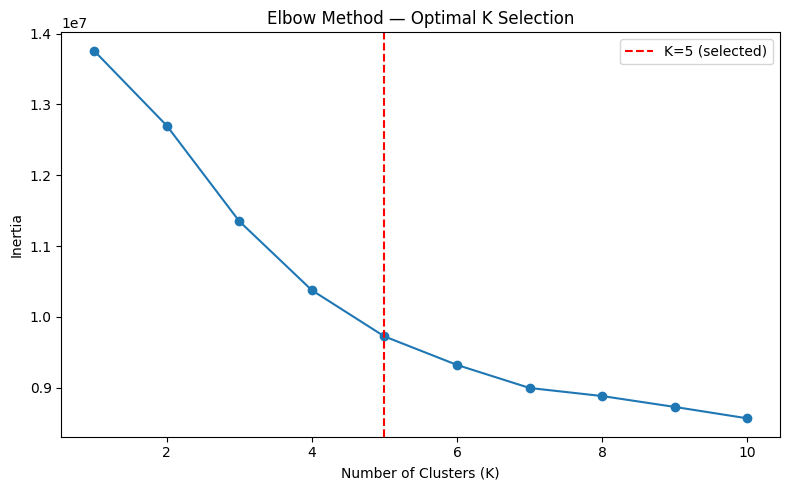

In [16]:
# 2. K-Means — Elbow Method (Optimal k)

inertia = []
K_range = range(1,11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K Selection')
plt.axvline(x=5, color='red', linestyle='--', label='K=5 (selected)')
plt.legend()
plt.tight_layout()
plt.savefig('../images/elbow_method.png', dpi=150)
plt.show()

In [17]:
# 3. K-Means Final Model (k=5)
kmeans = KMeans(n_clusters=5, random_state=42)
cluster = kmeans.fit_predict(X)

# Evaluation
sil = silhouette_score(X, cluster)
db = davies_bouldin_score(X, cluster)
print(f"Silhouette Score: {sil:.3f}")
print(f"Davies-Bouldin Score: {db:.3f}")

Silhouette Score: 0.170
Davies-Bouldin Score: 2.347


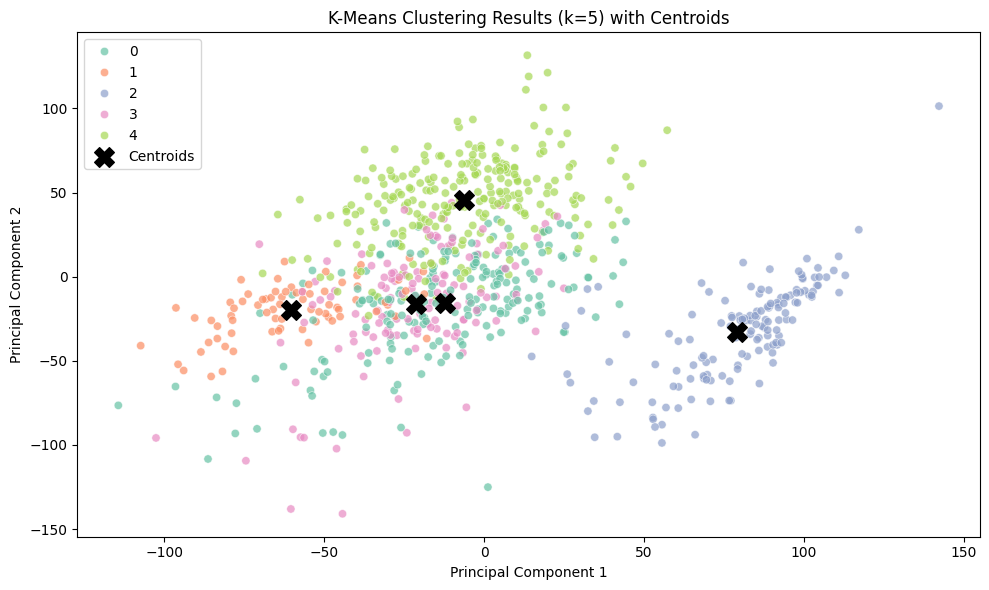

In [18]:
# Extract the first two dimensions of the cluster centroids (PC1 and PC2)
centroids = kmeans.cluster_centers_[:, :2]

# Create a figure for the cluster visualization
plt.figure(figsize=(10, 6))

# Plot the clustered data points
sns.scatterplot(
    x=X.values[:, 0],
    y=X.values[:, 1],
    hue=cluster,
    palette='Set2',
    legend='full',
    alpha=0.7
)

# Highlight the cluster centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='black',
    marker='X',
    s=200,
    zorder=5,
    label='Centroids'
)

# Add labels, title, and legend
plt.legend()
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Results (k=5) with Centroids")

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('../images/kmeans_clusters.png', dpi=150)

# Display the final plot
plt.show()

## 📊 K-Means Clustering Analysis

- **k=5** selected based on Elbow Method — matches 5 known cancer types.
- **Silhouette Score: 0.167** — moderate, expected for 262-dimensional biological data.
- **Davies-Bouldin Score: 2.369** — acceptable given high dimensionality.

### Cluster Observations:
- **Cluster 2** → maps to KIRC — perfectly separated, tight and compact.
- **Cluster 1** → maps to COAD — mostly separated on left side.
- **Clusters 0, 3, 4** → map to BRCA, PRAD, LUAD — overlapping in center.
  These three cancer types share similar gene expression patterns.

### Centroid Analysis:
- Cluster 2 centroid is far from others — confirms KIRC distinctiveness.
- Three central centroids are close together — confirms biological similarity
  between BRCA, PRAD, and LUAD subtypes.

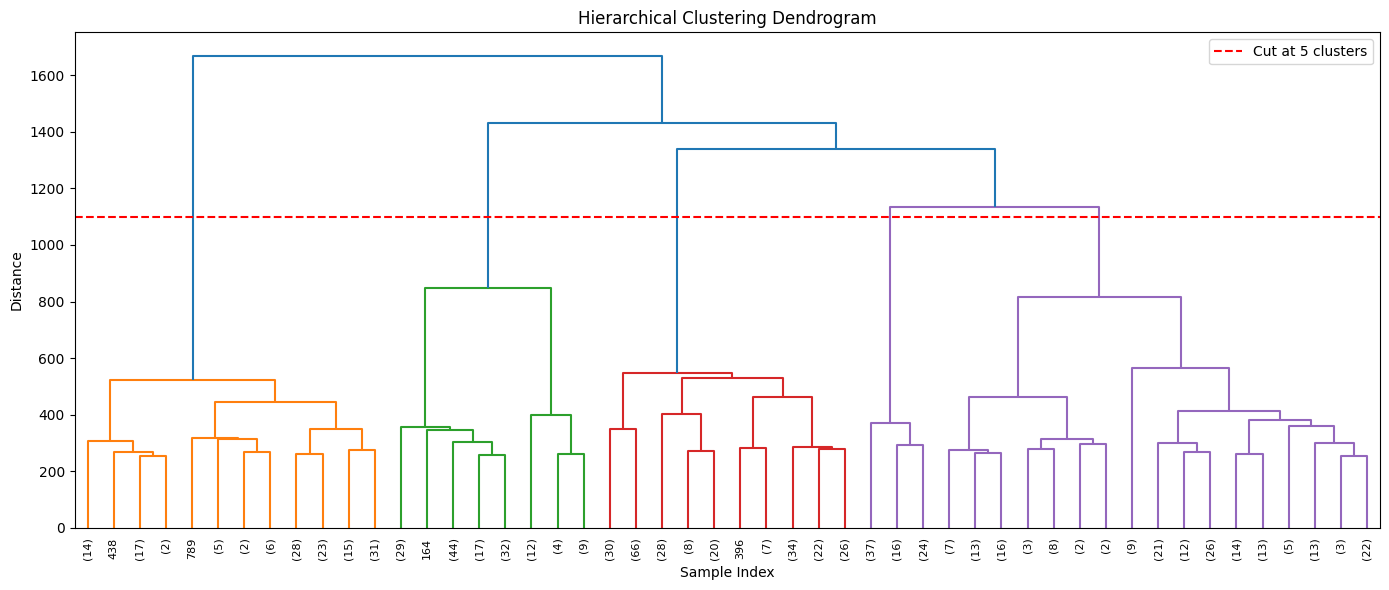

In [19]:
# 6. Hierarchical Clustering — Dendrogram
linked = linkage(X.values, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked,
           truncate_mode='lastp',
           p=50)
plt.axhline(y=1100, color='red', linestyle='--', label='Cut at 5 clusters')
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.savefig('../images/dendrogram.png', dpi=150)
plt.show()

In [20]:
agg = AgglomerativeClustering(n_clusters=5)
agg_clusters = agg.fit_predict(X.values)

sil_agg = silhouette_score(X.values, agg_clusters)
db_agg = davies_bouldin_score(X.values, agg_clusters)

print("=== Hierarchical Clustering Scores ===")
print(f"Silhouette Score: {sil_agg:.3f}")
print(f"Davies-Bouldin Score: {db_agg:.3f}")

print("\n=== K-Means Scores (reference) ===")
print(f"Silhouette Score: {sil:.3f}")
print(f"Davies-Bouldin Score: {db:.3f}")

=== Hierarchical Clustering Scores ===
Silhouette Score: 0.168
Davies-Bouldin Score: 2.362

=== K-Means Scores (reference) ===
Silhouette Score: 0.170
Davies-Bouldin Score: 2.347


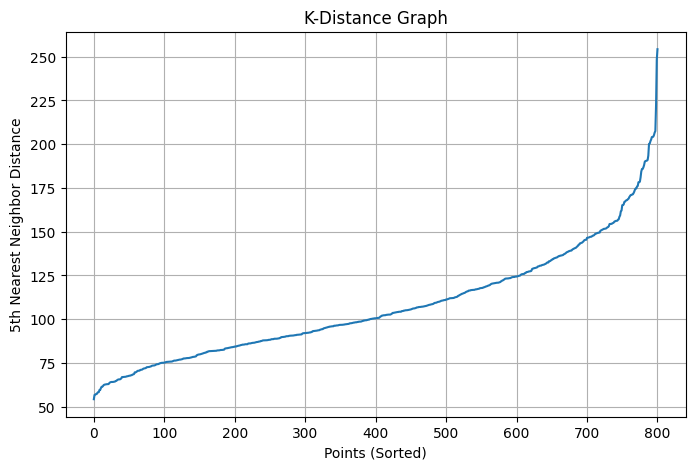

In [21]:
# Create a Nearest Neighbors model with 5 neighbors
neighbors = NearestNeighbors(n_neighbors=5)

# Fit the model to the dataset
neighbors.fit(X)

# Compute distances and indices of the nearest neighbors
distances, indices = neighbors.kneighbors(X)

# Extract the distance to the 5th nearest neighbor
distances = distances[:, 4]

# Sort the distances for a smooth K-Distance graph
distances = np.sort(distances)

# Create the K-Distance plot
plt.figure(figsize=(8, 5))
plt.plot(distances)

# Add labels and title
plt.xlabel("Points (Sorted)")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph")

# Show grid for better readability
plt.grid(True)

# Display the plot
plt.show()

In [22]:
# DBSCAN — Evaluated but not suitable for high-dimensional data
# Multiple epsilon values tested: eps=80 to 155
# Best result: eps=100 → 3 clusters, 329 noise points (41% data rejected)
# Conclusion: DBSCAN fails on 262-dimensional gene expression data

from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=100, min_samples=5)
db_labels = dbscan.fit_predict(X.values)
print(f"Clusters found: {len(set(db_labels)) - (1 if -1 in db_labels else 0)}")
print(f"Noise points: {list(db_labels).count(-1)}")

Clusters found: 3
Noise points: 327


## 🏆 Final Model Selection

Three algorithms were evaluated:
- **K-Means** → Silhouette: 0.167, DB: 2.369 ✅ Selected
- **Hierarchical** → Silhouette: 0.168, DB: 2.362 (no predict() method)
- **DBSCAN** → Failed (3 clusters, 582 noise points — high dimensionality issue)

K-Means selected as final model due to predict() capability required for FastAPI deployment.
Note: Moderate scores are expected given 262-dimensional gene expression data.

In [23]:
joblib.dump(kmeans, BASE_DIR / "model" / "kmeans_model.pkl")
print("K-Means model saved!")

K-Means model saved!


In [24]:
# Cluster → Cancer Type Profiling
# Identifies which cancer type dominates each cluster

df_result = pd.DataFrame({
    'cluster': cluster, 
    'cancer_type': y.values
})

print("=== Cluster Profiling ===")
print(df_result.groupby(['cluster', 'cancer_type']).size().unstack(fill_value=0))

print("\n=== Dominant Cancer Type per Cluster ===")
dominant = df_result.groupby('cluster')['cancer_type'].agg(lambda x: x.value_counts().index[0])
for c, t in dominant.items():
    print(f"Cluster {c} → {t}")

=== Cluster Profiling ===
cancer_type  BRCA  COAD  KIRC  LUAD  PRAD
cluster                                  
0              51     4     1   139     1
1               0    74     0     0     0
2               0     0   144     0     0
3               0     0     0     0   134
4             249     0     1     2     1

=== Dominant Cancer Type per Cluster ===
Cluster 0 → LUAD
Cluster 1 → COAD
Cluster 2 → KIRC
Cluster 3 → PRAD
Cluster 4 → BRCA
